## Load the Data

In [1]:
import pandas as pd

In [2]:
# Load the data into a DataFrame
df = pd.read_json('all.jsonl', lines=True)

In [3]:
# Seperate each answer into its own row
human_answers = df["human_answers"].explode()
gpt_answers = df["chatgpt_answers"].explode()


In [4]:
# Combine into a single DataFrame and shuffle
combined_df = pd.DataFrame({
    "text": pd.concat([human_answers, gpt_answers], ignore_index=False),
    "label": [0] * len(human_answers) + [1] * len(gpt_answers)
})
combined_df = combined_df.sample(frac=1, random_state=42)

Remember that human answers are labeled 0, and gpt answers are labeled 1!

In [5]:
# Split into training, validation, and test sets
num_samples = len(combined_df)
train = combined_df.iloc[:int(0.8 * num_samples)]
val = combined_df.iloc[int(0.8 * num_samples):int(0.9 * num_samples)]
test = combined_df.iloc[int(0.9 * num_samples):]

---
## Tokenize and Clean

In [6]:
import torch
from transformers import RobertaTokenizer, RobertaForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

In [7]:
# Check if GPU is available and set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [8]:
# Convert to Hugging Face Datasets and drop missing values
train_ds = Dataset.from_pandas(train.dropna())
val_ds = Dataset.from_pandas(val.dropna())
test_ds = Dataset.from_pandas(test.dropna())

In [9]:
# Load tokenizer and tokenize the data
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

def tokenize_function(samples):
    return tokenizer(
        samples['text'],
        padding='max_length',
        truncation=True,
        max_length=512
    )

# Tokenize all datasets
train_tokenized = train_ds.map(tokenize_function, batched=True)
val_tokenized = val_ds.map(tokenize_function, batched=True)
test_tokenized = test_ds.map(tokenize_function, batched=True)

# Set format for PyTorch
train_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
val_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

Map:   0%|          | 0/68361 [00:00<?, ? examples/s]

Map:   0%|          | 0/8547 [00:00<?, ? examples/s]

Map:   0%|          | 0/8541 [00:00<?, ? examples/s]

---
## Train roBERTa model

In [12]:
# Define model
model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=2
)

# Define training parameters
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
)

# Set up Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [13]:
# Run training
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.592293,0.626064
2,0.590369,0.640204
3,0.049633,0.024355


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.18it/s]


TrainOutput(global_step=25638, training_loss=0.29455181442251577, metrics={'train_runtime': 15367.7561, 'train_samples_per_second': 13.345, 'train_steps_per_second': 1.668, 'total_flos': 5.395960456639488e+16, 'train_loss': 0.29455181442251577, 'epoch': 3.0})

In [13]:
# Run instead of training to load model from checkpoint
model = RobertaForSequenceClassification.from_pretrained('./results/checkpoint-25638')

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
)

# Restore trainer from checkpoint
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [17]:
# Evaluate on test set
results = trainer.evaluate(test_tokenized)
print("Evaluation results:")
print(results)

Training Loss,Validation Loss,Epoch
No log,0.032149,0


Evaluation results:
{'eval_loss': 0.03214895725250244}


---
## Evaluate Model

In [14]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# Get predictions
predictions = trainer.predict(test_tokenized)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

In [16]:
# Full classification report
report_dict = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df = report_df.rename(index={"0": 'Human', "1": 'ChatGPT'})

report_df

,precision,recall,f1-score,support
Human,0.999150,0.992401,0.995764,5922.000000
ChatGPT,0.983076,0.998091,0.990527,2619.000000
accuracy,0.994146,0.994146,0.994146,0.994146
macro avg,0.991113,0.995246,0.993145,8541.000000
weighted avg,0.994221,0.994146,0.994158,8541.000000


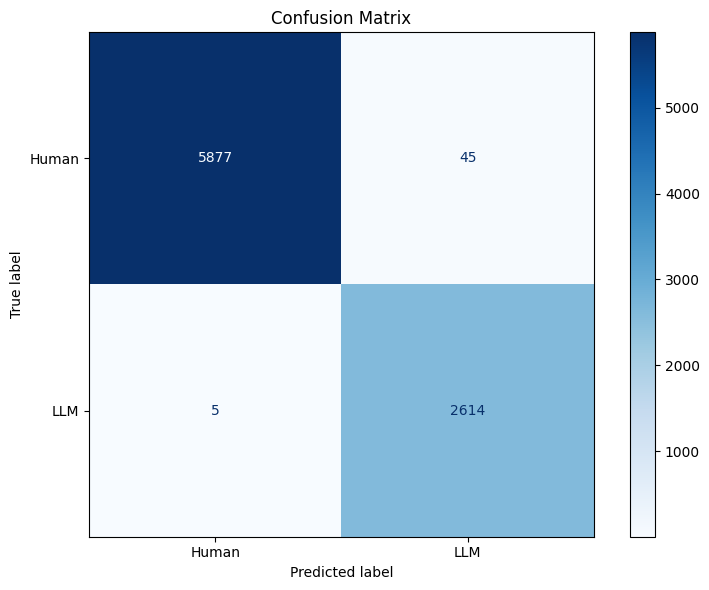

In [17]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'LLM']).plot(
    ax=ax, 
    cmap='Blues',
    values_format='d'
)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [18]:
from lime.lime_text import LimeTextExplainer

In [19]:
# Create a prediction function for LIME
def predict_with_model(texts):
    """Predict probabilities for a list of texts."""
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=512)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
    
    return probs.cpu().numpy()

def predict_proba(texts):
    """Wrapper for LIME - takes list of strings, returns array of probabilities."""
    return predict_with_model(texts)

# Create LIME explainer
explainer = LimeTextExplainer(class_names=['Human', 'LLM'])
print("LIME explainer created!")

LIME explainer created!


In [26]:
# Example: Explain a single prediction
# Get a sample from test data
sample_text = test.iloc[50]['text']
sample_label = test.iloc[50]['label']

print(f"Sample text:\n {sample_text}")
print(f"True label: {'LLM' if sample_label == 1 else 'Human'}")

# Generate explanation
explanation = explainer.explain_instance(
    sample_text, 
    predict_proba, 
    num_features=30,
    num_samples=500
)

Sample text:
 They give a look into historical events that may not be how it 's looked at normally . Someone writing a memoir about their experiences in the Vietnam War would have a widely different take on these events than someone who 's , say , writing a chapter in a history textbook explaining the different wars . It makes you look at these events from more than one perspective and hones in on the fact that these events were experienced differently by different kinds of people .
True label: Human


In [27]:
explanation.save_to_file('tmp.html')